In [ ]:
import json

kaggle_dict = {
    "username": "Sathya Mozhi",
    "key": "KGAT_a441b02dfc006e7ccb28cb7260013171"
}

with open("kaggle.json", "w") as file:
    json.dump(kaggle_dict, file)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d berkeleyearth/climate-change-earth-surface-temperature-data

# Unzip dataset
!unzip climate-change-earth-surface-temperature-data.zip

Dataset URL: https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data
License(s): CC-BY-NC-SA-4.0
 96% 81.0M/84.7M [00:00<00:00, 260MB/s]
100% 84.7M/84.7M [00:00<00:00, 255MB/s]
Archive:  climate-change-earth-surface-temperature-data.zip
  inflating: GlobalLandTemperaturesByCity.csv  
  inflating: GlobalLandTemperaturesByCountry.csv  
  inflating: GlobalLandTemperaturesByMajorCity.csv  
  inflating: GlobalLandTemperaturesByState.csv  
  inflating: GlobalTemperatures.csv  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

In [ ]:
df = pd.read_csv("GlobalLandTemperaturesByCountry.csv")

df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [ ]:
df = df[['AverageTemperature', 'Country']]

# Remove missing values
df = df.dropna()

# Reduce dataset size to avoid RAM crash
df = df.sample(30000, random_state=42)

df.head()

,AverageTemperature,Country
500353,26.420,Suriname
548987,15.614,United Kingdom (Europe)
189222,26.331,French Guiana
372731,9.445,New Zealand
489364,21.550,South Korea


In [ ]:
X = df[['AverageTemperature']]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,AverageTemperature,Country,Cluster
500353,26.420,Suriname,1
548987,15.614,United Kingdom (Europe),2
189222,26.331,French Guiana,1
372731,9.445,New Zealand,2
489364,21.550,South Korea,1


In [ ]:
new_data = pd.DataFrame({
    'AverageTemperature': [30]
})

new_data_scaled = scaler.transform(new_data)

cluster_prediction = kmeans.predict(new_data_scaled)

print("Predicted Cluster:", cluster_prediction[0])

Predicted Cluster: 1


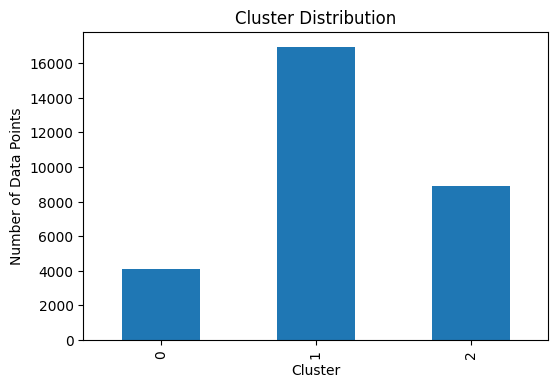

In [ ]:
plt.figure(figsize=(6,4))

df['Cluster'].value_counts().sort_index().plot(kind='bar')

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Data Points")

plt.show()

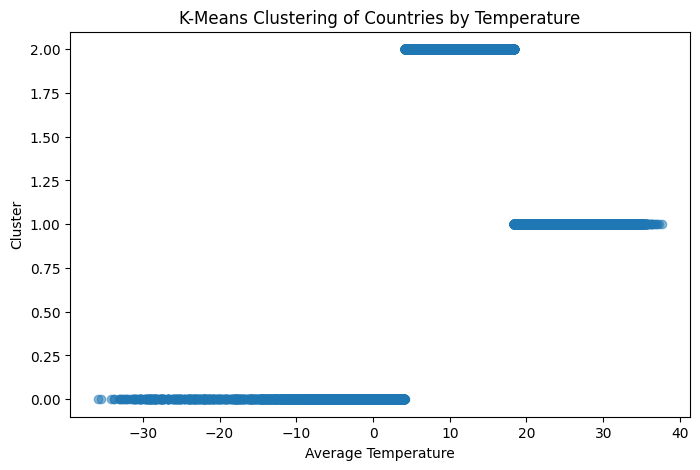

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['AverageTemperature'], df['Cluster'], alpha=0.5)

plt.title("K-Means Clustering of Countries by Temperature")
plt.xlabel("Average Temperature")
plt.ylabel("Cluster")

plt.show()

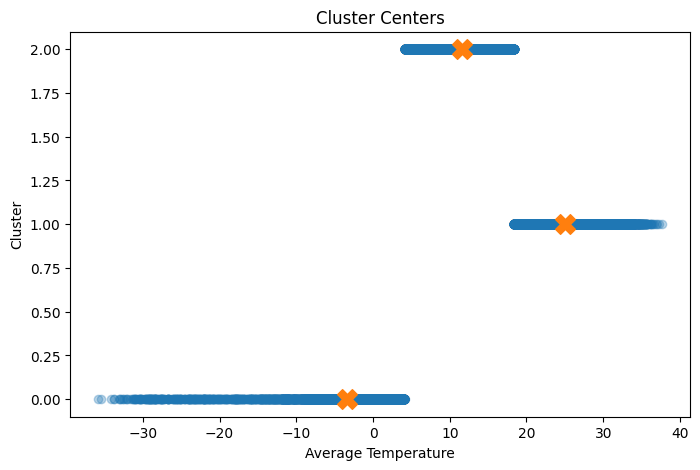

Cluster Centers (Actual Temperature Values):
[[-3.39427102]
 [25.07712974]
 [11.60070145]]


In [ ]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,5))

plt.scatter(df['AverageTemperature'], df['Cluster'], alpha=0.3)

plt.scatter(centers, [0,1,2], marker='X', s=200)

plt.title("Cluster Centers")
plt.xlabel("Average Temperature")
plt.ylabel("Cluster")

plt.show()

print("Cluster Centers (Actual Temperature Values):")
print(centers)

In [13]:
hier_model = AgglomerativeClustering(n_clusters=3)

df['Hierarchical_Cluster'] = hier_model.fit_predict(X_scaled)

df.head()

,AverageTemperature,Country,Cluster,Hierarchical_Cluster
500353,26.420,Suriname,1,1
548987,15.614,United Kingdom (Europe),2,0
189222,26.331,French Guiana,1,1
372731,9.445,New Zealand,2,0
489364,21.550,South Korea,1,1


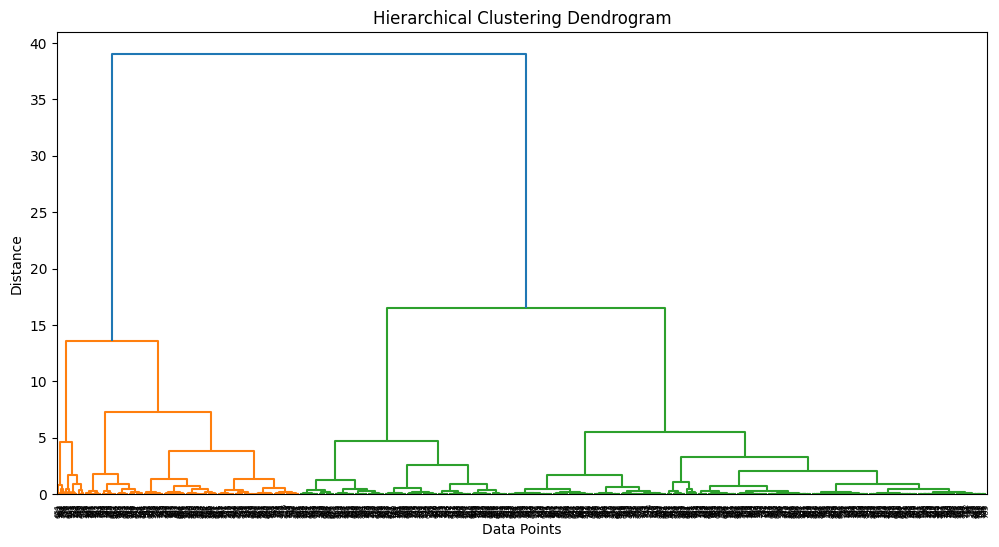

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use smaller sample to avoid RAM crash
sample_data = X_scaled[:1000]

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

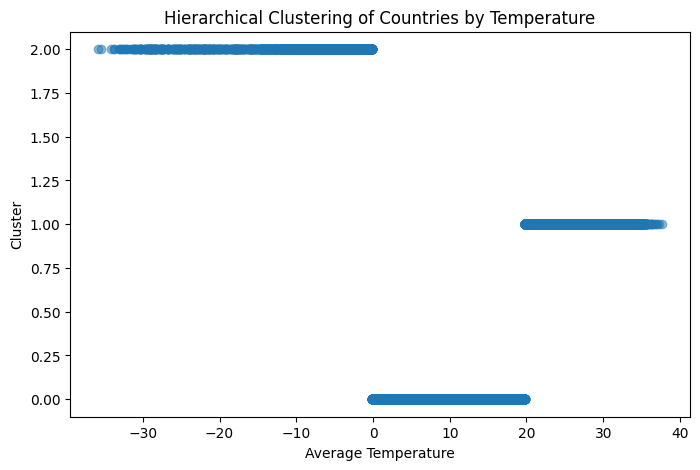

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df['AverageTemperature'],
            df['Hierarchical_Cluster'],
            alpha=0.5)

plt.title("Hierarchical Clustering of Countries by Temperature")
plt.xlabel("Average Temperature")
plt.ylabel("Cluster")

plt.show()

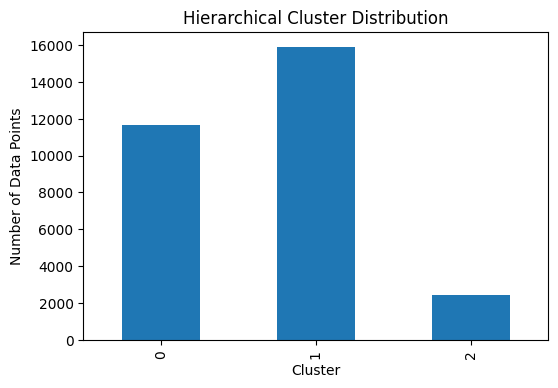

In [17]:
plt.figure(figsize=(6,4))

df['Hierarchical_Cluster'].value_counts().sort_index().plot(kind='bar')

plt.title("Hierarchical Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Data Points")

plt.show()

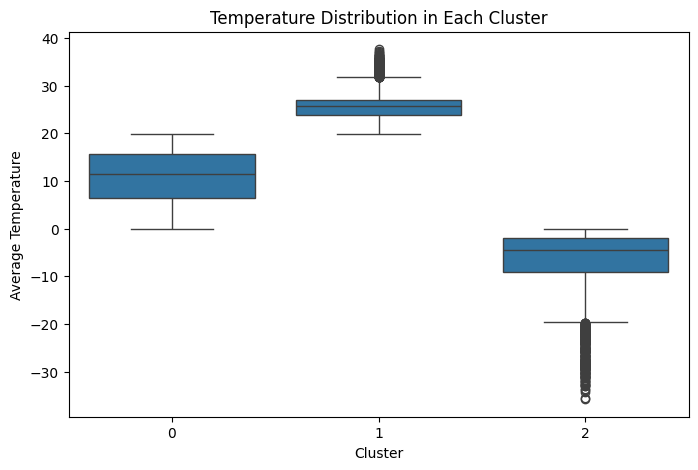

In [18]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Hierarchical_Cluster'],
            y=df['AverageTemperature'])

plt.title("Temperature Distribution in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Temperature")

plt.show()

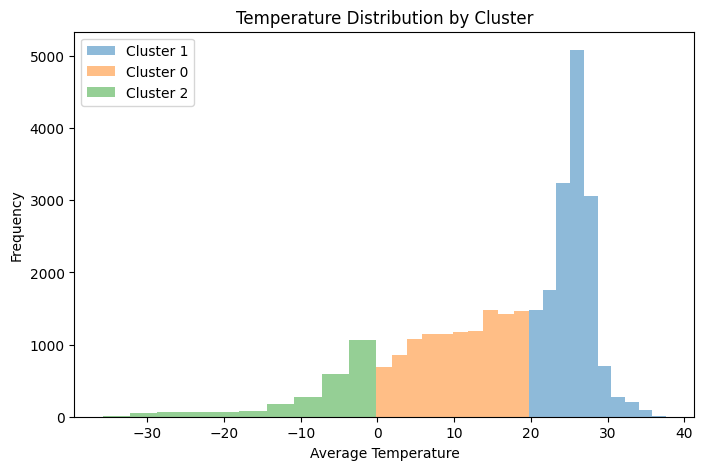

In [19]:
plt.figure(figsize=(8,5))

for cluster in df['Hierarchical_Cluster'].unique():
    subset = df[df['Hierarchical_Cluster'] == cluster]
    plt.hist(subset['AverageTemperature'], alpha=0.5, label=f"Cluster {cluster}")

plt.title("Temperature Distribution by Cluster")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.legend()

plt.show()